In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'
]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding = 4),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean = (0.4914, 0.4822, 0.4465),
                         std = (0.2023, 0.1994, 0.2010)   
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = (0.4914, 0.4822, 0.4465),
                         std = (0.2023, 0.1994, 0.2010)
    )
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=0)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle= False,  num_workers=0)

print(f"Training samples: {len(train_set)}")
print(f"Test samples:     {len(test_set)}")
print(f"Image shape:      {train_set[0][0].shape}")


Training samples: 50000
Test samples:     10000
Image shape:      torch.Size([3, 32, 32])


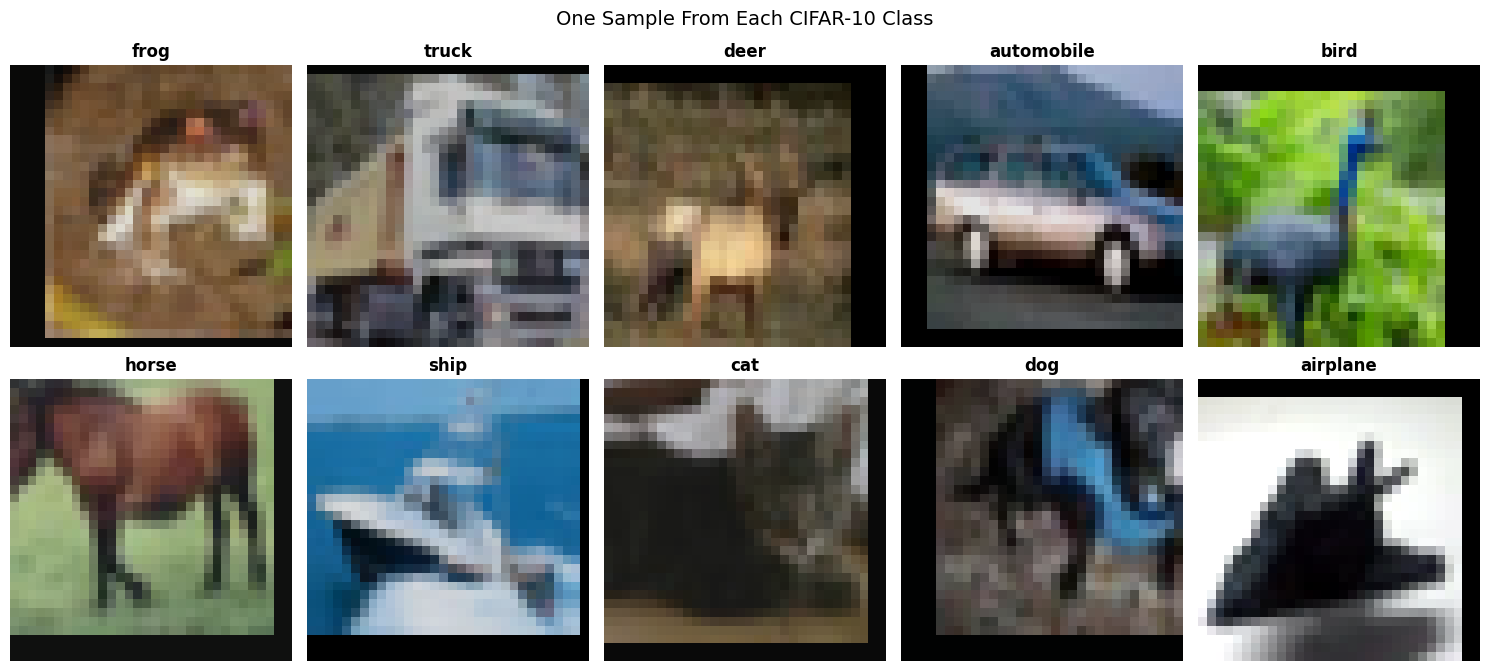

c:\Users\rohit\Desktop\deep-learning-journey\dl-venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


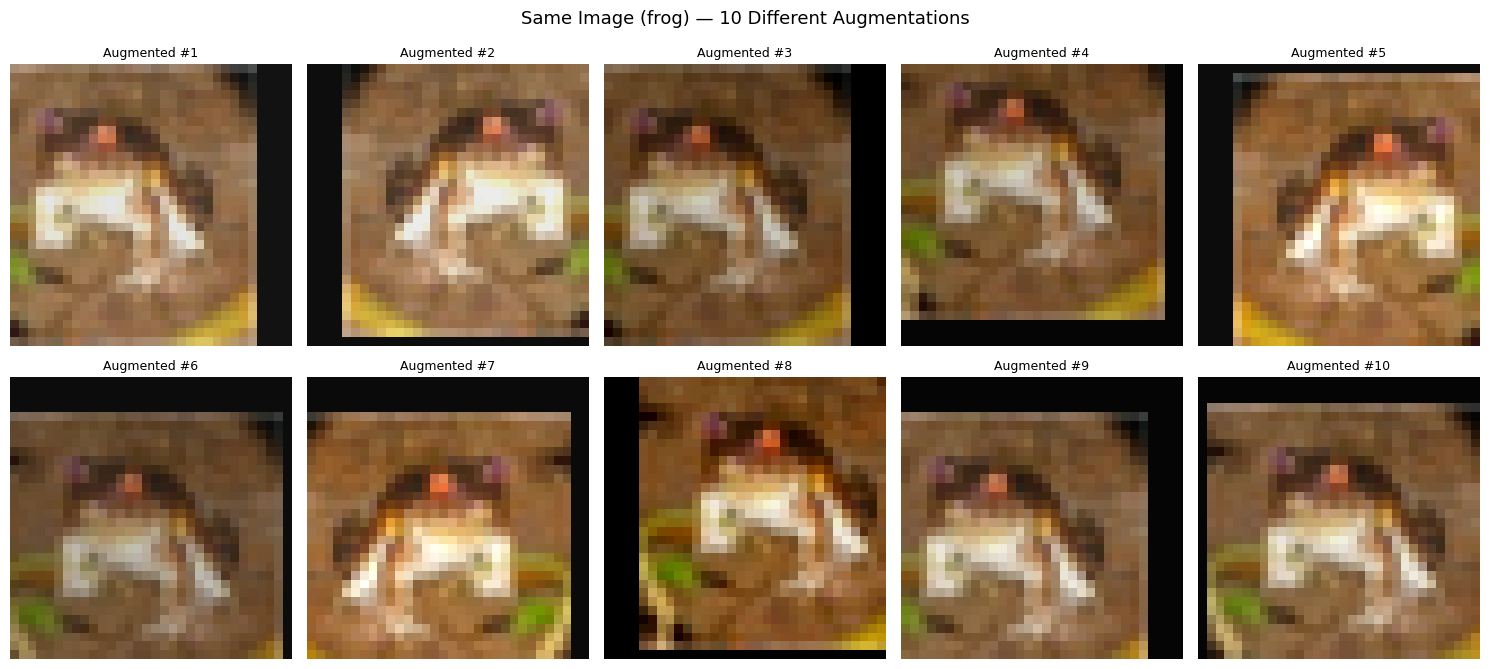

In [7]:
def imshow(img):
    img = img * torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)
    img = img + torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    img = torch.clamp(img, 0, 1)                                         # Clamping them into the valid display range.
    return img.permute(1, 2, 0).numpy()                                  # Permute done to match matplotlib's expected shape or columns.

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

shown = {i: False for i in range(10)}
count = 0

for image, label in train_set:
    if not shown[label]:
        row, col = count // 5, count % 5
        axes[row, col].imshow(imshow(image))
        axes[row, col].set_title(classes[label], fontsize=12, fontweight='bold')
        axes[row, col].axis('off')
        shown[label] = True
        count += 1
    if count == 10:
        break

plt.suptitle("One Sample From Each CIFAR-10 Class", fontsize=14)
plt.tight_layout()
plt.show()

raw_transform = transforms.ToTensor()
raw_set       = torchvision.datasets.CIFAR10('./data', train=True,
                                              download=False, transform=raw_transform)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
sample_img = raw_set[0][0]

for i, ax in enumerate(axes.flat):
    augmented = train_transform(transforms.ToPILImage()(sample_img))
    ax.imshow(imshow(augmented))
    ax.set_title(f"Augmented #{i+1}", fontsize=9)
    ax.axis('off')

plt.suptitle(f"Same Image ({classes[raw_set[0][1]]}) — 10 Different Augmentations", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
class CIFAR10Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.3)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.4)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

model = CIFAR10Net()
print(model)
print("Total Parameters : " , sum(p.numel() for p in model.parameters()))

# Shape trace
dummy = torch.randn(1, 3, 32, 32)
model.eval()
with torch.no_grad():
    out = model(dummy)
print(f"\nInput shape:  (1, 3, 32, 32)")
print(f"Output shape: {out.shape}")  # (1, 10)

 

CIFAR10Net(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7):

In [19]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = CIFAR10Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Cosine annealing — smoothly reduces LR over training
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

print(f"Training on: {device}")

history = {
    'train_loss': [], 'test_loss': [],
    'train_acc':  [], 'test_acc':  [],
    'lr':         []
}

best_acc         = 0.0
best_model_state = None

for epoch in range(20):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss    += loss.item()
        _, predicted   = torch.max(outputs, 1)
        train_total   += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    
    model.eval()
    test_loss, test_correct, test_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted  = torch.max(outputs, 1)
            test_total   += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    scheduler.step()

    # Recording history
    train_loss_avg = train_loss / len(train_loader)
    test_loss_avg  = test_loss  / len(test_loader)
    train_acc      = 100 * train_correct / train_total
    test_acc       = 100 * test_correct  / test_total
    current_lr     = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss_avg)
    history['test_loss'].append(test_loss_avg)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    history['lr'].append(current_lr)

    # Saving best model
    if test_acc > best_acc:
        best_acc         = test_acc
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        marker = " ← best "
    else:
        marker = ""

    print(f"Epoch {epoch+1:2d}/20 | "
          f"Train: {train_acc:.1f}% | "
          f"Test:  {test_acc:.1f}% | "
          f"LR: {current_lr:.6f}{marker}")

# Restoring best
model.load_state_dict(best_model_state)
print(f"\n🏆 Best Test Accuracy: {best_acc:.2f}%")
torch.save(best_model_state, 'projects/cifar10_model.pth')
print("Model saved!")


Training on: cuda
Epoch  1/20 | Train: 36.2% | Test:  51.7% | LR: 0.000994 ← best 
Epoch  2/20 | Train: 49.4% | Test:  60.5% | LR: 0.000976 ← best 
Epoch  3/20 | Train: 56.6% | Test:  67.4% | LR: 0.000946 ← best 
Epoch  4/20 | Train: 61.0% | Test:  69.9% | LR: 0.000905 ← best 
Epoch  5/20 | Train: 63.6% | Test:  73.3% | LR: 0.000854 ← best 
Epoch  6/20 | Train: 65.9% | Test:  74.6% | LR: 0.000794 ← best 
Epoch  7/20 | Train: 67.5% | Test:  74.7% | LR: 0.000727 ← best 
Epoch  8/20 | Train: 69.6% | Test:  76.9% | LR: 0.000655 ← best 
Epoch  9/20 | Train: 70.7% | Test:  78.1% | LR: 0.000578 ← best 
Epoch 10/20 | Train: 71.6% | Test:  78.4% | LR: 0.000500 ← best 
Epoch 11/20 | Train: 72.9% | Test:  79.1% | LR: 0.000422 ← best 
Epoch 12/20 | Train: 74.0% | Test:  80.0% | LR: 0.000345 ← best 
Epoch 13/20 | Train: 74.7% | Test:  81.0% | LR: 0.000273 ← best 
Epoch 14/20 | Train: 75.2% | Test:  81.3% | LR: 0.000206 ← best 
Epoch 15/20 | Train: 76.0% | Test:  82.0% | LR: 0.000146 ← best 
Epoch 1

Normally train accuracy is higher. Here test beats train — this is because Dropout is ON during training (randomly zeroing neurons makes training harder) but OFF during evaluation. The full network without dropout is stronger than the crippled training version.

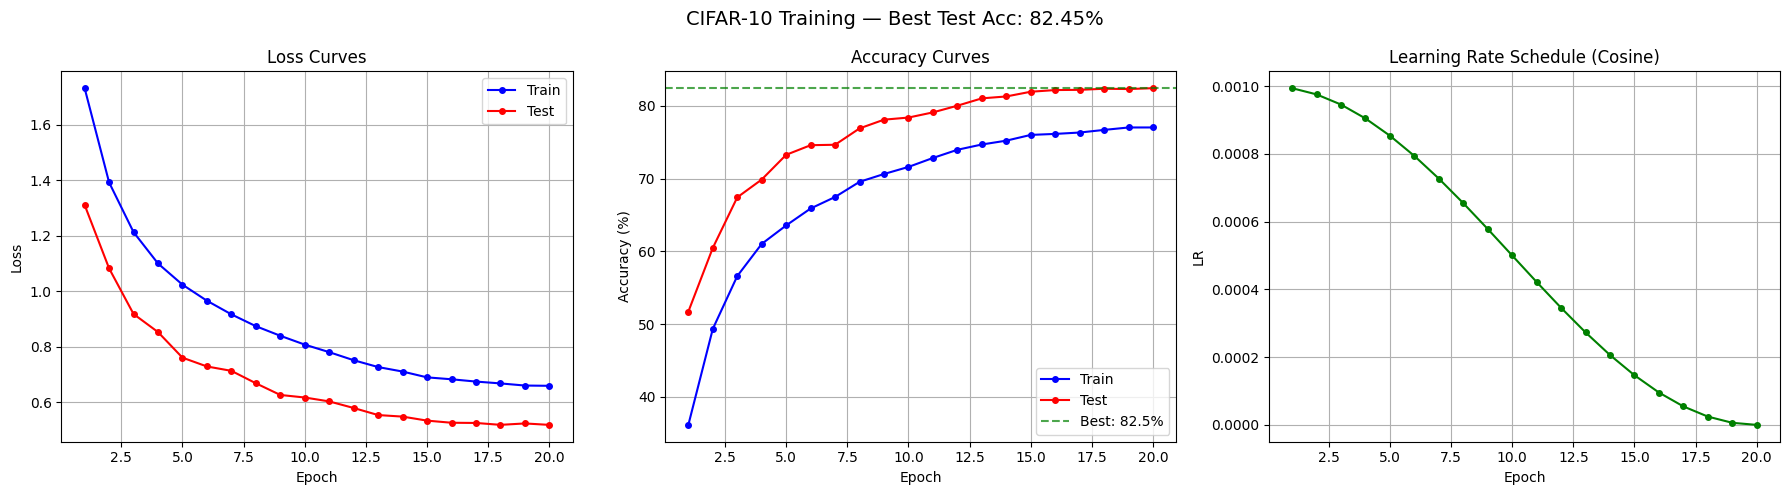

In [20]:
epochs = range(1, 21)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-o', ms=4, label='Train')
axes[0].plot(epochs, history['test_loss'],  'r-o', ms=4, label='Test')
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, history['train_acc'], 'b-o', ms=4, label='Train')
axes[1].plot(epochs, history['test_acc'],  'r-o', ms=4, label='Test')
axes[1].axhline(y=best_acc, color='green', linestyle='--',
                alpha=0.7, label=f'Best: {best_acc:.1f}%')
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True)

# Learning Rate Schedule
axes[2].plot(epochs, history['lr'], 'g-o', ms=4)
axes[2].set_title("Learning Rate Schedule (Cosine)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("LR")
axes[2].grid(True)

plt.suptitle(f"CIFAR-10 Training — Best Test Acc: {best_acc:.2f}%", fontsize=14)
plt.tight_layout()
plt.show()


In [21]:
# Which classes does the model struggle with most?
model.eval()
class_correct = [0] * 10
class_total   = [0] * 10

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs        = model(images)
        _, predicted   = torch.max(outputs, 1)

        for label, pred in zip(labels, predicted):
            class_total[label]  += 1
            if label == pred:
                class_correct[label] += 1

print("Per-class accuracy:")
print("-" * 40)
for i, cls in enumerate(classes):
    acc = 100 * class_correct[i] / class_total[i]
    bar = "█" * int(acc // 5)
    print(f"{cls:12s}: {acc:5.1f}% {bar}")

Per-class accuracy:
----------------------------------------
airplane    :  82.3% ████████████████
automobile  :  93.3% ██████████████████
bird        :  70.1% ██████████████
cat         :  61.6% ████████████
deer        :  83.4% ████████████████
dog         :  76.2% ███████████████
frog        :  89.9% █████████████████
horse       :  85.4% █████████████████
ship        :  89.5% █████████████████
truck       :  92.8% ██████████████████


Cat gets confused with:
- dog   → similar body shape, four legs, fur texture, similar size
- deer  → similar face structure at 32×32 resolution
- frog  → similar crouching posture in some images

At 32×32 pixels, a cat and dog are nearly indistinguishable
even to the human eye sometimes

c:\Users\rohit\Desktop\deep-learning-journey\dl-venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


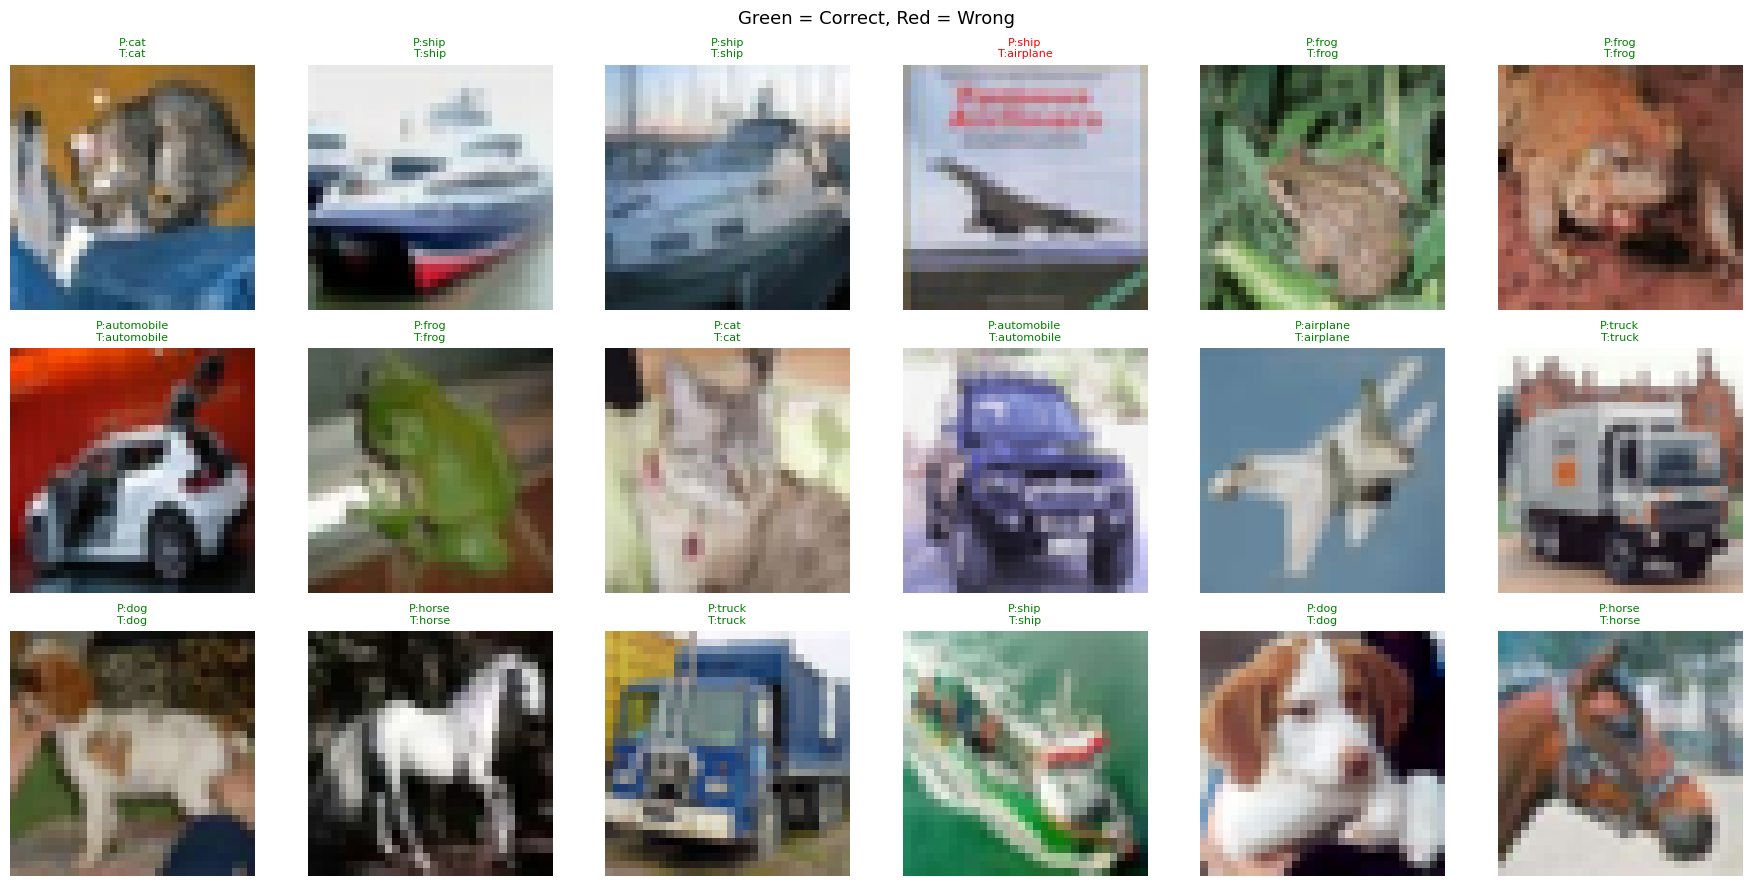

In [22]:
# Visualizing predictions — correct (green) vs wrong (red)
model.eval()
test_images_raw  = torchvision.datasets.CIFAR10(
    './data', train=False, download=False,
    transform=transforms.ToTensor()
)

batch_imgs, batch_labels = next(iter(test_loader))
with torch.no_grad():
    outputs      = model(batch_imgs.to(device))
    _, predicted = torch.max(outputs, 1)

# Unnormalize for display
mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for i, ax in enumerate(axes.flat):
    img   = batch_imgs[i] * std + mean
    img   = torch.clamp(img, 0, 1).permute(1, 2, 0).numpy()
    pred  = predicted[i].item()
    true  = batch_labels[i].item()
    color = 'green' if pred == true else 'red'

    ax.imshow(img)
    ax.set_title(f"P:{classes[pred]}\nT:{classes[true]}",
                 color=color, fontsize=8)
    ax.axis('off')

plt.suptitle("Green = Correct, Red = Wrong", fontsize=13)
plt.tight_layout()
plt.show()
